# 01 · Calidad de los datasets KOSIS (fuente maestra)

KOSIS/KOSTAT es la **fuente maestra** de nacimientos, TFR, población por sexo y edad, EAPS y proyecciones oficiales.
El perfilamiento solo cubre esas variables: completitud, rangos, duplicados y consistencia interna, con las metas del documento (≥95 % nacional, ≥90 % regional).
Usa los archivos de `data/bronze/kosis/` leídos con `src/transform/lectura_bronze.py` y las dimensiones de `config/mappings/`.

In [1]:
import sys; from pathlib import Path; sys.path.insert(0, str(Path.cwd().parent))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.quality import lectura_bronze as lb
from src.quality import perfilamiento as pf

pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:,.3f}".format)

dim_terr = pd.read_csv(Path.cwd().parent / "config" / "mappings" / "territorios.csv", dtype=str)
ANIOS = range(2000, 2026)
NACIONAL = {"Whole country", "Total"}          # etiqueta del total nacional según archivo
EXCLUIR = {"Jeonnam-Gwangju"}                   # región combinada que no está en dim_territorio
SEJONG = {"Sejong", "sejong-si"}
resumen = []                                    # una fila por variable de interés y nivel


def completitud_niveles(df, por, inicio_sejong=2012):
    """% de celdas con dato: nacional, regional (17 si-do) y regional sin la ausencia estructural de Sejong."""
    c = pf.completitud(df, por, ANIOS).reset_index()
    nac, reg = c[c.territorio.isin(NACIONAL)], c[~c.territorio.isin(NACIONAL)].copy()
    pct = lambda x: round(x.anios_con_dato.sum() / x.anios_esperados.sum() * 100, 1)
    reg_sin = reg.copy()
    reg_sin.loc[reg_sin.territorio.isin(SEJONG), "anios_esperados"] = 2025 - inicio_sejong + 1
    return {"nacional": pct(nac), "regional": pct(reg), "regional_sin_estructural": pct(reg_sin)}, c


def periodo(df):
    a = df.loc[df.valor.notna(), "anio"]
    return f"{a.min()}-{a.max()}"

## 1. Carga de los archivos bronze

In [2]:
vit, tfr_raw, vit_nac = lb.kosis_vitales_sido(), lb.kosis_tfr_sido(), lb.kosis_vitales_nacional()
eaps_raw, eaps_se_raw = lb.kosis_eaps_sido(), lb.kosis_eaps_sexo_edad()
pob_sido, pob_nac, proy_esc = lb.kosis_poblacion_sido(), lb.kosis_poblacion_nacional(), lb.kosis_proyeccion_escenarios()

carga = {"vitales_sido": vit, "tfr_sido": tfr_raw, "vitales_nacional": vit_nac, "eaps_sido": eaps_raw,
         "eaps_sexo_edad": eaps_se_raw, "poblacion_sido": pob_sido, "poblacion_nacional": pob_nac,
         "proyeccion_escenarios": proy_esc}
pd.DataFrame({k: {"filas": len(d), "anios": f"{d.anio.min()}-{d.anio.max()}",
                  "territorios": d.territorio.nunique() if "territorio" in d else 1,
                  "nulos_valor": int(d.valor.isna().sum())} for k, d in carga.items()}).T

,filas,anios,territorios,nulos_valor
vitales_sido,7410,2000-2025,19,557
tfr_sido,3744,2000-2025,18,96
vitales_nacional,416,2000-2025,1,4
eaps_sido,4446,2000-2025,19,378
eaps_sexo_edad,6240,2000-2025,1,0
poblacion_sido,65826,2000-2052,18,828
poblacion_nacional,5037,2000-2072,1,0
proyeccion_escenarios,94248,2022-2072,1,0


## 2. Nacimientos y TFR (nacional + si-do, 2000-2025)
Ítems maestros: `Live births(persons)` del archivo de vitales si-do y `Total Fertility Rate` del archivo de TFR si-do (3 decimales).

In [3]:
nac = vit[(vit["item"] == "Live births(persons)") & ~vit.territorio.isin(EXCLUIR)]
tfr = tfr_raw[tfr_raw["item"] == "Total Fertility Rate"]

# Jeonnam-Gwangju: ¿solo 2025 y = Gwangju + Jeollanam-do? (justifica excluirlo)
jg = vit[(vit["item"] == "Live births(persons)") & (vit.anio == 2025)].set_index("territorio").valor
print("Jeonnam-Gwangju 2025:", jg["Jeonnam-Gwangju"], "| Gwangju + Jeollanam-do:", jg["Gwangju"] + jg["Jeollanam-do"])

cal = {}
for nombre, df, rmax in [("NACIMIENTOS", nac, None), ("TFR", tfr, 10)]:
    comp, tabla = completitud_niveles(df, ["territorio"])
    cal[nombre] = dict(comp, fuera_rango=len(pf.fuera_de_rango(df.dropna(subset=["valor"]), 0, rmax)),
                       duplicados=pf.duplicados(df, ["territorio", "anio"]), periodo=periodo(df),
                       incompletos=", ".join(f"{r.territorio} ({r.anios_con_dato}/26)" for r in tabla.itertuples() if r.completitud_pct < 100))
display(pd.DataFrame(cal).T)

ancho =lambda df: df.pivot(index="anio", columns="territorio", values="valor")
n_w, t_w = ancho(nac), ancho(tfr)
nac_arch = vit_nac[vit_nac["item"] == "Live births(persons)"].set_index("anio").valor
tfr_arch = vit_nac[vit_nac["item"] == "Total fertility rate(persons)"].set_index("anio").valor
tfr_vit = ancho(vit[vit["item"] == "Total Fertility Rate(persons)"])

cons_nac = {
    "NAC: |suma 17 si-do − nacional| máx": (n_w.drop(columns="Whole country").sum(axis=1) - n_w["Whole country"]).abs().max(),
    "NAC: |nacional si-do − archivo nacional| máx": (n_w["Whole country"] - nac_arch).abs().max(),
    "TFR: |nacional si-do − archivo nacional| máx": (t_w["Whole country"] - tfr_arch).abs().max(),
    "TFR: |archivo TFR − archivo vitales (2 dec.)| máx": (tv := t_w.rename(columns={"sejong-si": "Sejong"})).sub(tfr_vit[tv.columns]).abs().max().max(),
}
display(pd.Series(cons_nac, name="valor").to_frame())

c = cal["NACIMIENTOS"]
resumen += [
    dict(variable="Nacimientos", nivel="nacional", periodo=c["periodo"], completitud=c["nacional"], completitud_sin_estructural=c["nacional"],
         fuera_rango=c["fuera_rango"], duplicados=c["duplicados"], consistencia=f"= archivo nacional (dif {cons_nac['NAC: |nacional si-do − archivo nacional| máx']:.0f})"),
    dict(variable="Nacimientos", nivel="si-do", periodo=c["periodo"], completitud=c["regional"], completitud_sin_estructural=c["regional_sin_estructural"],
         fuera_rango=c["fuera_rango"], duplicados=c["duplicados"], consistencia=f"Σ17 si-do = nacional (dif {cons_nac['NAC: |suma 17 si-do − nacional| máx']:.0f})"),
]
c = cal["TFR"]
resumen += [
    dict(variable="TFR", nivel="nacional", periodo=c["periodo"], completitud=c["nacional"], completitud_sin_estructural=c["nacional"],
         fuera_rango=c["fuera_rango"], duplicados=c["duplicados"], consistencia=f"= archivo nacional (dif {cons_nac['TFR: |nacional si-do − archivo nacional| máx']:.3f})"),
    dict(variable="TFR", nivel="si-do", periodo=c["periodo"], completitud=c["regional"], completitud_sin_estructural=c["regional_sin_estructural"],
         fuera_rango=c["fuera_rango"], duplicados=c["duplicados"], consistencia=f"vs vitales 2 dec. (dif ≤ {cons_nac['TFR: |archivo TFR − archivo vitales (2 dec.)| máx']:.3f})"),
]

Jeonnam-Gwangju 2025: 15214.0 | Gwangju + Jeollanam-do: 15214.0


,nacional,regional,regional_sin_estructural,fuera_rango,duplicados,periodo,incompletos
NACIMIENTOS,100.000,97.300,100.000,0,0,2000-2025,Sejong (14/26)
TFR,100.000,97.300,100.000,0,0,2000-2025,sejong-si (14/26)


,valor
NAC: |suma 17 si-do − nacional| máx,0.000
NAC: |nacional si-do − archivo nacional| máx,0.000
TFR: |nacional si-do − archivo nacional| máx,0.000
TFR: |archivo TFR − archivo vitales (2 dec.)| máx,0.005


## 3. Población por sexo y edad, histórico 2000-2025 (`kosis_poblacion_sido`)
Se excluyen del cuadre de edades el `Total` y el agregado `80 Years old & over`, que duplica 80-84 … 100+.
Luego se calculan los derivados del proyecto (`PROP_65MAS`, `INDICE_ENVEJECIMIENTO` = 65+/0-14×100, `DEPENDENCIA_VEJEZ` = 65+/15-64×100), solo para verificar que son plausibles.

In [4]:
pob = pob_sido[pob_sido.anio.isin(ANIOS)].copy()
pob["edad_n"] = pob.edad.str.extract(r"^(\d+)")[0].astype(float)           # inicio del grupo; NaN = Total
AGREG_80 = "80 Years old & over"
base = pob[(pob.edad != "Total") & (pob.edad != AGREG_80)]

comp_pob, tabla_pob = completitud_niveles(pob, ["territorio", "sexo", "edad"])
clave = ["territorio", "sexo", "edad", "anio"]
w_sexo = pob.pivot_table(index=["territorio", "edad", "anio"], columns="sexo", values="valor")
tot = pob[pob.edad == "Total"].set_index(["territorio", "sexo", "anio"]).valor
w_ter = pob.pivot_table(index=["sexo", "edad", "anio"], columns="territorio", values="valor")
s80 = base[base.edad_n >= 80].groupby(["territorio", "sexo", "anio"]).valor.sum()
a80 = pob[pob.edad == AGREG_80].set_index(["territorio", "sexo", "anio"]).valor

cons_pob = {
    "|H + M − Total| máx": (w_sexo.Male + w_sexo.Female - w_sexo.Total).abs().max(),
    "|Σ grupos quinquenales − Total| máx": (base.groupby(["territorio", "sexo", "anio"]).valor.sum() - tot).abs().max(),
    "|Σ 17 si-do − Whole country| máx": (w_ter.drop(columns="Whole country").sum(axis=1, min_count=1) - w_ter["Whole country"]).abs().max(),
    "|agregado 80+ − Σ(80-84…100+)| máx": (s80 - a80).abs().max(),
    "grupo abierto de la fuente": base.loc[base.edad_n.idxmax(), "edad"],
}
print(comp_pob, "| fuera de rango (<0):", len(pf.fuera_de_rango(pob.dropna(subset=["valor"]), 0)),
      "| duplicados:", pf.duplicados(pob, clave))
print("Incompletos:", tabla_pob[tabla_pob.completitud_pct < 100].groupby("territorio").anios_con_dato.agg(["min", "max", "size"]).to_dict("index"))
pd.Series(cons_pob, name="valor").to_frame()

{'nacional': np.float64(100.0), 'regional': np.float64(97.3), 'regional_sin_estructural': np.float64(100.0)} | fuera de rango (<0): 0 | duplicados: 0
Incompletos: {'Sejong': {'min': 14, 'max': 14, 'size': 69}}


,valor
|H + M − Total| máx,0.000
|Σ grupos quinquenales − Total| máx,0.000
|Σ 17 si-do − Whole country| máx,0.000
|agregado 80+ − Σ(80-84…100+)| máx,0.000
grupo abierto de la fuente,100 Years old & over


In [5]:
g = base[base.sexo == "Total"].assign(grupo=pd.cut(base.loc[base.sexo == "Total", "edad_n"], [-1, 14, 64, 200], labels=["0-14", "15-64", "65+"]))
g = g.pivot_table(index=["territorio", "anio"], columns="grupo", values="valor", aggfunc="sum", observed=True)
der = pd.DataFrame({"PROP_65MAS": g["65+"] / g.sum(axis=1) * 100,
                    "INDICE_ENVEJECIMIENTO": g["65+"] / g["0-14"] * 100,
                    "DEPENDENCIA_VEJEZ": g["65+"] / g["15-64"] * 100}).dropna()
sido25 = der.xs(2025, level="anio").drop(index="Whole country")
tabla_der = pd.concat({"nacional 2000": der.loc[("Whole country", 2000)], "nacional 2025": der.loc[("Whole country", 2025)],
                       "si-do 2025 mín": sido25.min(), "si-do 2025 máx": sido25.max()}, axis=1).round(1)
tabla_der["si-do máx 2025"] = sido25.idxmax()
print("Valores fuera de [0, 100] en PROP_65MAS:", int((~der.PROP_65MAS.between(0, 100)).sum()))
display(tabla_der)

resumen += [
    dict(variable="Población sexo×edad", nivel=nivel, periodo=periodo(pob), completitud=comp_pob[k], completitud_sin_estructural=comp_pob[k2],
         fuera_rango=len(pf.fuera_de_rango(pob.dropna(subset=["valor"]), 0)), duplicados=pf.duplicados(pob, clave),
         consistencia=f"H+M, Σedades, Σsi-do: dif máx {max(cons_pob['|H + M − Total| máx'], cons_pob['|Σ grupos quinquenales − Total| máx'], cons_pob['|Σ 17 si-do − Whole country| máx']):.0f}; "
                      "fuente hasta 100+ (agregar 85+); 2022-2025 = proyección medio")
    for nivel, k, k2 in [("nacional", "nacional", "nacional"), ("si-do", "regional", "regional_sin_estructural")]
]
resumen.append(dict(variable="Derivados (65+, envejec., dependencia)", nivel="nacional + si-do", periodo=periodo(pob), completitud=None,
                    completitud_sin_estructural=None, fuera_rango=int((~der.PROP_65MAS.between(0, 100)).sum()), duplicados=0,
                    consistencia="rangos plausibles (ver tabla)"))

Valores fuera de [0, 100] en PROP_65MAS:

 0


,nacional 2000,nacional 2025,si-do 2025 mín,si-do 2025 máx,si-do máx 2025
PROP_65MAS,7.200,20.300,11.600,27.400,Jeollanam-do
INDICE_ENVEJECIMIENTO,34.300,199.900,67.400,280.300,Gyeongsangbuk-do
DEPENDENCIA_VEJEZ,10.100,29.300,16.300,43.600,Jeollanam-do


## 4. EAPS por si-do (miles de personas y %)
Se usa el promedio anual publicado por KOSIS. Las tolerancias fijas son ±1 mil para activos = ocupados + desocupados y ±0.1 pp para las tasas recalculadas.
Además se compara cada caso con la cota teórica del error por redondeo a miles, que es mayor donde el denominador es pequeño.

In [6]:
ITEMS = {"Population 15 years old and over (Thousand Person)": "pob15", "Economically active population (Thousand Person)": "activos",
         "Employed persons (Thousand Person)": "ocupados", "Unemployed persons (Thousand Person)": "desocupados",
         "Labor Force Participation rate (%)": "tasa_part", "Unemployment rate (%)": "tasa_desemp"}
eaps = eaps_raw[eaps_raw["item"].isin(ITEMS) & ~eaps_raw.territorio.isin(EXCLUIR)].assign(item=lambda d: d["item"].map(ITEMS))
comp_eaps, tabla_eaps = completitud_niveles(eaps, ["territorio", "item"], inicio_sejong=2017)
tasas = eaps[eaps["item"].str.startswith("tasa")].dropna(subset=["valor"])
fr_eaps = len(pf.fuera_de_rango(tasas, 0, 100)) + len(pf.fuera_de_rango(eaps[~eaps["item"].str.startswith("tasa")].dropna(subset=["valor"]), 0))
dup_eaps = pf.duplicados(eaps, ["territorio", "item", "anio"])

w = eaps.pivot_table(index=["territorio", "anio"], columns="item", values="valor")
d_act = (w.activos - w.ocupados - w.desocupados).abs()
d_tp = (w.activos / w.pob15 * 100 - w.tasa_part).abs()
d_td = (w.desocupados / w.activos * 100 - w.tasa_desemp).abs()
niveles = ["pob15", "activos", "ocupados", "desocupados"]
reg = w.drop(index="Total", level="territorio")[niveles].groupby("anio").sum()
d_sum = (reg - w.xs("Total", level="territorio")[niveles]).abs()

# Cota de error teórica por redondeo de una tasa a/b×100: niveles a ±0.5 mil y tasa publicada a ±0.05 pp
cota = lambda a, b: 50 / b * (1 + a / b) + 0.05
fuera_cota_tp, fuera_cota_td = d_tp > cota(w.activos, w.pob15), d_td > cota(w.desocupados, w.activos)

print(comp_eaps, "| fuera de rango:", fr_eaps, "| duplicados:", dup_eaps)
cons_eaps = pd.DataFrame({
    "dif máx": [d_act.max(), d_tp.max(), d_td.max(), d_sum.max().max()],
    "casos > tolerancia fija": [int((d_act > 1).sum()), int((d_tp > 0.1).sum()), int((d_td > 0.1).sum()), int((d_sum > 17).sum().sum())],
    "tolerancia fija": ["±1 mil", "±0.1 pp", "±0.1 pp", "±17 mil (17 × redondeo)"],
    "casos > cota de redondeo": [None, int(fuera_cota_tp.sum()), int(fuera_cota_td.sum()), None]},
    index=["activos = ocupados + desocupados", "tasa part. ≈ activos/pob15×100", "tasa desemp. ≈ desoc./activos×100", "Σ17 si-do = Total (niveles)"])
display(cons_eaps)
fuera_tp = d_tp[d_tp > 0.1].rename("dif_pp").reset_index().merge(w.pob15.reset_index(), on=["territorio", "anio"])
print(f"Tasa part. > ±0.1 pp: {len(fuera_tp)} casos en {sorted(fuera_tp.territorio.unique())}; pob15 de esos casos: {fuera_tp.pob15.min():.0f}-{fuera_tp.pob15.max():.0f} mil")

def txt_eaps(m):   # m = máscara del nivel sobre el índice (territorio, anio)
    return (f"act=ocu+des >±1: {int((d_act[m] > 1).sum())}; tasas >±0.1 pp: {int((d_tp[m] > 0.1).sum())} part. / {int((d_td[m] > 0.1).sum())} desemp. "
            f"(fuera de cota de redondeo: {int(fuera_cota_tp[m].sum() + fuera_cota_td[m].sum())})")
es_total = w.index.get_level_values("territorio") == "Total"
resumen += [
    dict(variable="EAPS (niveles y tasas)", nivel="nacional", periodo=periodo(eaps), completitud=comp_eaps["nacional"], completitud_sin_estructural=comp_eaps["nacional"],
         fuera_rango=fr_eaps, duplicados=dup_eaps, consistencia=txt_eaps(es_total)),
    dict(variable="EAPS (niveles y tasas)", nivel="si-do", periodo=periodo(eaps), completitud=comp_eaps["regional"], completitud_sin_estructural=comp_eaps["regional_sin_estructural"],
         fuera_rango=fr_eaps, duplicados=dup_eaps, consistencia=txt_eaps(~es_total) + f"; Σsi-do vs Total ≤{d_sum.max().max():.0f} mil"),
]

{'nacional': np.float64(100.0), 'regional': np.float64(96.2), 'regional_sin_estructural': np.float64(100.0)} | fuera de rango: 0 | duplicados: 0


,dif máx,casos > tolerancia fija,tolerancia fija,casos > cota de redondeo
activos = ocupados + desocupados,1.000,0,±1 mil,NaN
tasa part. ≈ activos/pob15×100,0.161,16,±0.1 pp,0.000
tasa desemp. ≈ desoc./activos×100,0.332,14,±0.1 pp,0.000
Σ17 si-do = Total (niveles),4.000,0,±17 mil (17 × redondeo),NaN


Tasa part. > ±0.1 pp: 16 casos en ['Jeju-do', 'Sejong', 'Ulsan']; pob15 de esos casos: 211-902 mil


## 5. EAPS nacional por sexo y edad
Grupos base que no se solapan: 15-19, 20-29, 30-39, 40-49, `50-59 Yeras old` (sic) y 60+. Los agregados 15-24, 15-29 y 15-64 no se suman.

In [7]:
BASE_EAPS = ["15-19 Years old", "20-29 Years old", "30-39 Years old", "40-49 Years old", "50-59 Yeras old", "60 Years old and over"]
se = eaps_se_raw[eaps_se_raw["item"].isin(ITEMS)].assign(item=lambda d: d["item"].map(ITEMS))
c_se = pf.completitud(se, ["sexo", "edad", "item"], ANIOS)
comp_se = round(c_se.anios_con_dato.sum() / c_se.anios_esperados.sum() * 100, 1)
fr_se = len(pf.fuera_de_rango(se[se["item"].str.startswith("tasa")].dropna(subset=["valor"]), 0, 100))
dup_se = pf.duplicados(se, ["sexo", "edad", "item", "anio"])
lv = se[~se["item"].str.startswith("tasa")]
ws = lv.pivot_table(index=["edad", "item", "anio"], columns="sexo", values="valor")
d_hm = (ws.Male + ws.Female - ws.Total).abs()
d_ed = (lv[lv.edad.isin(BASE_EAPS)].groupby(["sexo", "item", "anio"]).valor.sum()
        - lv[lv.edad == "Total"].set_index(["sexo", "item", "anio"]).valor).abs()
d_tot = (lv[(lv.sexo == "Total") & (lv.edad == "Total")].set_index(["item", "anio"]).valor
         - w.xs("Total", level="territorio")[niveles].stack().swaplevel().rename_axis(["item", "anio"])).abs()
print(f"Completitud: {comp_se} % | fuera de rango: {fr_se} | duplicados: {dup_se}")
display(pd.DataFrame({"dif máx (miles)": [d_hm.max(), d_ed.max(), d_tot.max()]},
                     index=["H + M − Total", "Σ grupos base − Total", "Total vs fila Total EAPS si-do"]))
resumen.append(dict(variable="EAPS sexo×edad", nivel="nacional", periodo=periodo(se), completitud=comp_se, completitud_sin_estructural=comp_se,
                    fuera_rango=fr_se, duplicados=dup_se,
                    consistencia=f"H+M dif ≤{d_hm.max():.0f}, Σedades dif ≤{d_ed.max():.0f} mil; grupos decenales y 60+ abierto"))

Completitud: 100.0 % | fuera de rango: 0 | duplicados: 0


,dif máx (miles)
H + M − Total,1.000
Σ grupos base − Total,2.000
Total vs fila Total EAPS si-do,0.000


## 6. Proyecciones oficiales KOSTAT
Nacional 2022-2072 con 3 escenarios (medio del archivo nacional; alto/bajo = `높은/낮은 출산율 추계` del archivo de escenarios) y provincial medio 2022-2052.
Ajuste local: las etiquetas de edad se normalizan quitando espacios (`"0 - 4세"` vs `"0-4세"`) y se excluye `80세이상`.

In [8]:
SEXO_KO = {"전체": "T", "남자": "H", "여자": "M"}
def norm_proy(df, escenario, edicion):
    d = df[df.edad != "80세이상"].copy()
    d["edad"] = d.edad.str.replace(" ", "", regex=False)
    return d.assign(sexo=d.sexo.map(SEXO_KO), escenario=escenario, edicion_proyeccion=edicion)

ED_N = "KOSTAT_2022_2072"
proy = pd.concat([norm_proy(pob_nac[pob_nac.anio >= 2022], "medio", ED_N),
                  norm_proy(proy_esc[proy_esc.escenario.str.startswith("높은 출산율 추계")], "alto", ED_N),
                  norm_proy(proy_esc[proy_esc.escenario.str.startswith("낮은 출산율 추계")], "bajo", ED_N)], ignore_index=True)
clave_p = ["escenario", "sexo", "edad", "anio"]
c_p = pf.completitud(proy, ["escenario", "sexo", "edad"], range(2022, 2073)).groupby("escenario").completitud_pct.mean()
p22 = proy[proy.anio == 2022].pivot_table(index=["sexo", "edad"], columns="escenario", values="valor")
wp = proy.pivot_table(index=["escenario", "edad", "anio"], columns="sexo", values="valor")
tot_p = proy[proy.edad == "계"].set_index(["escenario", "sexo", "anio"]).valor
d_ed_p = (proy[proy.edad != "계"].groupby(["escenario", "sexo", "anio"]).valor.sum() - tot_p).abs()

cons_proy = {"completitud % por escenario": c_p.to_dict(),
             "grupos de edad por escenario": proy.groupby("escenario").edad.nunique().to_dict(),
             "2022 igual en los 3 escenarios (dif máx)": (p22.max(axis=1) - p22.min(axis=1)).max(),
             "|H + M − T| máx": (wp.H + wp.M - wp["T"]).abs().max(),
             "|Σ edades − Total| máx": d_ed_p.max(),
             "fuera de rango (<0)": len(pf.fuera_de_rango(proy.dropna(subset=["valor"]), 0)),
             "duplicados": pf.duplicados(proy, clave_p),
             "Total 2072 (millones)": (tot_p.xs("T", level="sexo").xs(2072, level="anio") / 1e6).round(2).to_dict()}
pd.Series(cons_proy, name="nacional").to_frame()

,nacional
completitud % por escenario,"{'alto': 100.0, 'bajo': 100.0, 'medio': 100.0}"
grupos de edad por escenario,"{'alto': 22, 'bajo': 22, 'medio': 22}"
2022 igual en los 3 escenarios (dif máx),0.000
|H + M − T| máx,0.000
|Σ edades − Total| máx,0
fuera de rango (<0),0
duplicados,0
Total 2072 (millones),"{'medio': 36.22, 'alto': 38.73, 'bajo': 33.92}"


In [9]:
prov = pob_sido[pob_sido.anio >= 2022].assign(escenario="medio", edicion_proyeccion="KOSTAT_2022_2052")
prov = prov[prov.edad != AGREG_80]
c_prov = pf.completitud(prov, ["territorio", "sexo", "edad"], range(2022, 2053))
wpt = prov.pivot_table(index=["sexo", "edad", "anio"], columns="territorio", values="valor")
wps = prov.pivot_table(index=["territorio", "edad", "anio"], columns="sexo", values="valor")
tot_prov = prov[prov.edad == "Total"].set_index(["territorio", "sexo", "anio"]).valor
nac_medio = pob_nac[(pob_nac.anio.between(2022, 2052)) & (pob_nac.edad == "계") & (pob_nac.sexo == "전체")].set_index("anio").valor
cons_prov = {"completitud %": round(c_prov.anios_con_dato.sum() / c_prov.anios_esperados.sum() * 100, 1),
             "|Σ 17 si-do − Whole country| máx": (wpt.drop(columns="Whole country").sum(axis=1) - wpt["Whole country"]).abs().max(),
             "|Whole country − archivo nacional medio| máx": (wpt.loc[("Total", "Total")]["Whole country"] - nac_medio).abs().max(),
             "|H + M − Total| máx": (wps.Male + wps.Female - wps.Total).abs().max(),
             "|Σ edades − Total| máx": (prov[prov.edad != "Total"].groupby(["territorio", "sexo", "anio"]).valor.sum() - tot_prov).abs().max(),
             "fuera de rango (<0)": len(pf.fuera_de_rango(prov, 0)), "duplicados": pf.duplicados(prov, ["territorio", "sexo", "edad", "anio"])}

# KPI: registros de proyección con edición y escenario identificados (meta 100 %)
todo = pd.concat([proy, prov])
kpi_proy = round(todo[["edicion_proyeccion", "escenario"]].notna().all(axis=1).mean() * 100, 1)
print(f"KPI registros de proyección con edición y escenario: {kpi_proy} % de {len(todo):,} registros")
display(pd.Series(cons_prov, name="provincial medio").to_frame())

resumen += [
    dict(variable="Proyección población (3 escenarios)", nivel="nacional", periodo=periodo(proy),
         completitud=round(c_p.mean(), 1), completitud_sin_estructural=round(c_p.mean(), 1),
         fuera_rango=cons_proy["fuera de rango (<0)"], duplicados=cons_proy["duplicados"],
         consistencia=f"2022 común (dif {cons_proy['2022 igual en los 3 escenarios (dif máx)']:.0f}); H+M, Σedades dif ≤{max(cons_proy['|H + M − T| máx'], cons_proy['|Σ edades − Total| máx']):.0f}; KPI ed.+esc. {kpi_proy} %"),
    dict(variable="Proyección población (medio)", nivel="si-do", periodo=periodo(prov), completitud=cons_prov["completitud %"],
         completitud_sin_estructural=cons_prov["completitud %"], fuera_rango=cons_prov["fuera de rango (<0)"], duplicados=cons_prov["duplicados"],
         consistencia=f"Σsi-do = nacional (dif {cons_prov['|Σ 17 si-do − Whole country| máx']:.0f}); = archivo nacional (dif {cons_prov['|Whole country − archivo nacional medio| máx']:.0f})"),
]

KPI registros de proyección con edición y escenario: 100.0 % de 46,926 registros


,provincial medio
completitud %,100.000
|Σ 17 si-do − Whole country| máx,0.000
|Whole country − archivo nacional medio| máx,0.000
|H + M − Total| máx,0.000
|Σ edades − Total| máx,0.000
fuera de rango (<0),0.000
duplicados,0.000


## 7. Homologación de etiquetas de territorio
Etiquetas de cada archivo que **no** coinciden con `nombre_en` de `territorios.csv`, con el código propuesto para silver.
Debajo, el mapa de completitud territorio × año de las cuatro variables regionales (único gráfico), que muestra dónde están las ausencias.

In [10]:
PROPUESTA = {"Whole country": "00", "Total": "00", "Gyeonggi-do": "31", "Gangwon-do": "32", "Chungcheongbuk-do": "33",
             "Chungcheongnam-do": "34", "Jeollabuk-do": "35", "Jeollanam-do": "36", "Gyeongsangbuk-do": "37",
             "Gyeongsangnam-do": "38", "sejong-si": "29", "Jeju-do": "39", "Jeonnam-Gwangju": "EXCLUIR"}
archivos = {"vitales_sido": vit, "tfr_sido": tfr_raw, "eaps_sido": eaps_raw, "poblacion_sido": pob_sido}
et = pd.concat([pd.DataFrame({"etiqueta": d.territorio.unique(), "archivo": k}) for k, d in archivos.items()])
et = et[~et.etiqueta.isin(dim_terr.nombre_en)]
homolog = et.groupby("etiqueta").archivo.agg(", ".join).to_frame()
homolog["cod_territorio"] = homolog.index.map(PROPUESTA)
homolog["nombre_en (dim)"] = homolog.cod_territorio.map(dim_terr.set_index("cod_territorio").nombre_en).fillna("—")
print("Sin propuesta:", sorted(set(homolog.index) - set(PROPUESTA)) or "ninguna")
print("Otras dimensiones a homologar → sexo:", sorted(set(pob_sido.sexo) | set(pob_nac.sexo)),
      "| edad: mayúsculas/errores ('years old', 'year old', 'Yeras') y espacios en coreano ('0 - 4세' vs '0-4세')")
homolog.sort_values("cod_territorio")

Sin propuesta: ninguna


Otras dimensiones a homologar → sexo: ['Female', 'Male', 'Total', '남자', '여자', '전체'] | edad: mayúsculas/errores ('years old', 'year old', 'Yeras') y espacios en coreano ('0 - 4세' vs '0-4세')


,archivo,cod_territorio,nombre_en (dim)
etiqueta,,,
Total,eaps_sido,00,South Korea
Whole country,"vitales_sido, tfr_sido, poblacion_sido",00,South Korea
sejong-si,tfr_sido,29,Sejong
Gyeonggi-do,"vitales_sido, tfr_sido, eaps_sido, poblacion_sido",31,Gyeonggi
Gangwon-do,"vitales_sido, tfr_sido, eaps_sido, poblacion_sido",32,Gangwon
Chungcheongbuk-do,"vitales_sido, tfr_sido, eaps_sido, poblacion_sido",33,North Chungcheong
Chungcheongnam-do,"vitales_sido, tfr_sido, eaps_sido, poblacion_sido",34,South Chungcheong
Jeollabuk-do,"vitales_sido, tfr_sido, eaps_sido, poblacion_sido",35,Jeonbuk
Jeollanam-do,"vitales_sido, tfr_sido, eaps_sido, poblacion_sido",36,South Jeolla


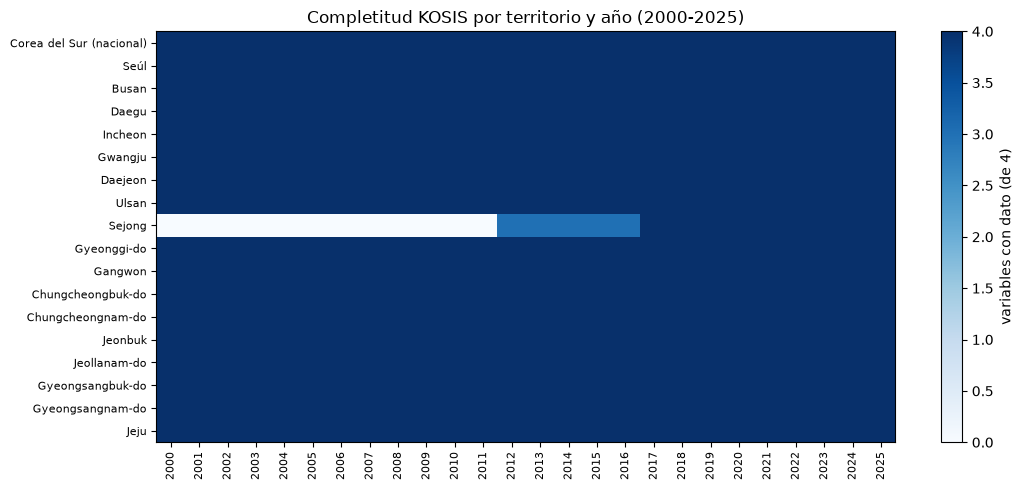

In [11]:
cod = lambda s: s.map(lambda x: PROPUESTA.get(x, dict(zip(dim_terr.nombre_en, dim_terr.cod_territorio)).get(x)))
series = {"Nacimientos": nac, "TFR": tfr, "Población": pob[(pob.sexo == "Total") & (pob.edad == "Total")],
          "EAPS activos": eaps[eaps["item"] == "activos"]}
nom = dim_terr.set_index("cod_territorio").nombre_es
mat = sum(d.assign(cod=cod(d.territorio)).pivot_table(index="cod", columns="anio", values="valor", aggfunc="count")
          .reindex(columns=ANIOS).fillna(0).clip(upper=1) for d in series.values())
mat.index = mat.index.map(nom)
fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(mat.values, cmap="Blues", vmin=0, vmax=4, aspect="auto")
ax.set_xticks(range(len(ANIOS)), ANIOS, rotation=90, fontsize=8); ax.set_yticks(range(len(mat)), mat.index, fontsize=8)
fig.colorbar(im, ax=ax, label="variables con dato (de 4)"); ax.set_title("Completitud KOSIS por territorio y año (2000-2025)")
plt.tight_layout(); plt.show()

## 8. Resumen de calidad por variable y nivel
Estado: **Bloqueante** si hay valores fuera de rango, duplicados o completitud (sin ausencias estructurales) por debajo de la meta; **Observación** si cumple pero hay ausencias estructurales o una limitación a tratar en silver; **OK** en el resto.

In [12]:
res = pd.DataFrame(resumen)
meta = np.where(res.nivel == "si-do", 90, 95)
OBS = {"Población sexo×edad", "EAPS sexo×edad"}   # limitaciones documentadas abajo
bloq = (res.fuera_rango > 0) | (res.duplicados > 0) | (res.completitud_sin_estructural.fillna(100) < meta)
obs = (res.completitud.fillna(100) < res.completitud_sin_estructural.fillna(100)) | res.variable.isin(OBS)
res["meta_%"] = np.where(res.completitud.isna(), None, meta)
res["estado"] = np.select([bloq, obs], ["Bloqueante", "Observación"], "OK")
res = res.rename(columns={"completitud": "completitud_%", "completitud_sin_estructural": "completitud_sin_estruct_%"})
with pd.option_context("display.max_colwidth", 120, "display.float_format", "{:.1f}".format):
    display(res)

,variable,nivel,periodo,completitud_%,completitud_sin_estruct_%,fuera_rango,duplicados,consistencia,meta_%,estado
0,Nacimientos,nacional,2000-2025,100.0,100.0,0,0,= archivo nacional (dif 0),95,OK
1,Nacimientos,si-do,2000-2025,97.3,100.0,0,0,Σ17 si-do = nacional (dif 0),90,Observación
2,TFR,nacional,2000-2025,100.0,100.0,0,0,= archivo nacional (dif 0.000),95,OK
3,TFR,si-do,2000-2025,97.3,100.0,0,0,vs vitales 2 dec. (dif ≤ 0.005),90,Observación
4,Población sexo×edad,nacional,2000-2025,100.0,100.0,0,0,"H+M, Σedades, Σsi-do: dif máx 0; fuente hasta 100+ (agregar 85+); 2022-2025 = proyección medio",95,Observación
5,Población sexo×edad,si-do,2000-2025,97.3,100.0,0,0,"H+M, Σedades, Σsi-do: dif máx 0; fuente hasta 100+ (agregar 85+); 2022-2025 = proyección medio",90,Observación
6,"Derivados (65+, envejec., dependencia)",nacional + si-do,2000-2025,NaN,NaN,0,0,rangos plausibles (ver tabla),None,OK
7,EAPS (niveles y tasas),nacional,2000-2025,100.0,100.0,0,0,act=ocu+des >±1: 0; tasas >±0.1 pp: 0 part. / 0 desemp. (fuera de cota de redondeo: 0),95,OK
8,EAPS (niveles y tasas),si-do,2000-2025,96.2,100.0,0,0,act=ocu+des >±1: 0; tasas >±0.1 pp: 16 part. / 14 desemp. (fuera de cota de redondeo: 0); Σsi-do vs Total ≤4 mil,90,Observación
9,EAPS sexo×edad,nacional,2000-2025,100.0,100.0,0,0,"H+M dif ≤1, Σedades dif ≤2 mil; grupos decenales y 60+ abierto",95,Observación


## 9. Hallazgos y acciones para silver
- **Sin bloqueantes**: no hay valores fuera de rango ni duplicados en la clave natural, y todas las variables cumplen la meta de completitud (≥95 % nacional, ≥90 % regional), incluso contando las ausencias estructurales.
- **Ausencias estructurales (no son errores)**: Sejong no tiene datos en 2000-2011 para nacimientos, TFR y población (es si-do desde 2012) ni en 2000-2016 para la EAPS. Con ellas la completitud regional es 97.3 % (nacimientos, TFR, población) y 96.2 % (EAPS); sin ellas, 100 %. → No van a `ctl.rechazos`: se construye el agregado `CNSJ` (Chungnam+Sejong) y, en la EAPS, sus tasas se recalculan desde los niveles.
- **Consistencia interna**: nacimientos, TFR, población y proyecciones cuadran exacto (Σ17 si-do = nacional, H+M = Total, Σedades = Total, provincial = nacional, los 3 escenarios coinciden en 2022). En la EAPS si-do, 16 tasas de participación y 14 de desempleo difieren más de ±0.1 pp del valor recalculado, en regiones con denominador pequeño (sobre todo Jeju y Sejong; también Ulsan y Daejeon), pero ninguna supera la cota teórica de redondeo. → En `validate.py`, usar para las tasas una tolerancia derivada del redondeo y no ±0.1 fijo; ±1 mil en identidades de niveles.
- **Población 2022-2025 es proyección**: según la tabla fuente (`config.yaml`), la población por si-do y la nacional son estimación solo hasta 2021; 2022-2025 son del escenario medio. → En `fact_historico`, marcarlas con `estado`/nota o reemplazarlas por la estimación actualizada.
- **Edades**: la fuente llega a 100+ y el diseño usa 85+ como grupo abierto. → Agregar 85-89 … 100+ en silver y descartar `80 Years old & over`/`80세이상`, que cuadran exacto con la suma de sus grupos. La EAPS por sexo y edad solo trae grupos decenales y 60+ abierto. → Supuesto explícito en el escenario 6b: la tasa de 60+ se aplica a 60-64 y a 65+.
- **Homologación**: 13 etiquetas de territorio no coinciden con `nombre_en`. Todas tienen código propuesto: `Whole country`/`Total` → `00`, `sejong-si` → `29`, `Jeju-do` → `39`, y los nombres con `-do` o antiguos (`Gangwon-do`, `Jeollabuk-do`) → su código en `dim_territorio`. `Jeonnam-Gwangju` solo aparece en 2025, es igual a Gwangju + Jeollanam-do y se excluye. Sexo y edad también deben homologarse (inglés/coreano, `Yeras`, espacios). Los archivos no traen `edicion_proyeccion`: se asigna desde `config.yaml` (KPI 100 %).